<a href="https://colab.research.google.com/github/islajanep777/FUNDAI-Laboratories-Pueblas/blob/main/Lab6_Naive_Bayes_Pueblas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: Naive Bayes Classifier from Scratch and with Scikit-learn

## Fundamentals of Artificial Intelligence

**Name:** Isla Jane L. Pueblas

**Course:** BSCSAI

**Section:** 09282 FUNDAI

**Date:** September 24, 2026

**Dataset Source (GitHub raw URL):**
https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv

**GitHub URL:** https://github.com/islajanep777

## Description
This laboratory implements a Naive Bayes classifier from scratch and compares it with the Scikit-learn implementation. The dataset is loaded directly from GitHub.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB, CategoricalNB

## Loading the Dataset from GitHub

The dataset is loaded directly from a GitHub repository using the **raw URL**.
A normal GitHub webpage (blob) URL will not work with 'pd.read_cvs()'

In [49]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(GITHUB_RAW_URL)

print("Dataset shape:", df.shape)
print()
print(df.head())
print()
print("Class distribution:")
print(df["species"].value_counts())

Dataset shape: (150, 5)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [50]:
feature_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

X = df[feature_columns].values
y = df["species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (105, 4)
Testing samples: (45, 4)


## From-Scratch Gaussian Naive Bayes

The classifier uses:

- Prior probability: P(class)
- Gaussian likelihood: P(feature | class)
- Log-posterior: log P(class) + sum of log likelihoods

Log probabilities are used to avoid numerical underflow.

In [51]:
class GaussianNaiveBayesScratch:
  def __init__(self, var_smoothing=1e-9):
    self.var_smoothing = var_smoothing

  def fit(self, X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    self.classes_ = np.unique(y)
    self.priors_ = {}
    self.means_ = {}
    self.variances_ = {}

    total_samples = len(y)

    for c in self.classes_:
      X_c = X[y == c]
      self.priors_[c] = len(X_c) / total_samples
      self.means_[c] = np.mean(X_c, axis=0)
      self.variances_[c] = X_c.var(axis=0) + self.var_smoothing

    return self

  def _log_likelihood(self, x, c):
    mu = self.means_[c]
    var = self.variances_[c]

    term1 = -0.5 * np.sum(np.log(2 * np.pi * var))
    term2 = -0.5 * np.sum((x - mu) ** 2 / var)

    return term1 + term2

  def _log_posterior(self, x, c):
    return np.log(self.priors_[c]) + self._log_likelihood(x, c)

  def predict(self, X):
    X = np.asarray(X, dtype=float)
    predictions = []

    for x in X:
      scores = {
          c: self._log_posterior(x, c)
          for c in self.classes_
      }
      best_class = max(scores, key=scores.get)
      predictions.append(best_class)

    return np.array(predictions)

In [52]:
scratch_model = GaussianNaiveBayesScratch()
scratch_model.fit(X_train, y_train)

scratch_predictions = scratch_model.predict(X_test)

scratch_accuracy = accuracy_score(y_test, scratch_predictions)

print("From-Scratch Gaussian Naive Bayes")
print("=" * 50)
print("Accuracy:", scratch_accuracy)
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, scratch_predictions))
print()
print(classification_report(y_test, scratch_predictions))

From-Scratch Gaussian Naive Bayes
Accuracy: 0.9111111111111111

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## Scikit-learn GaussianNB

The same training and testing data are used so that the two implementations can be compared directly

In [53]:
sklearn_model = GaussianNB()
sklearn_model.fit(X_train, y_train)

sklearn_predictions = sklearn_model.predict(X_test)

sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)

print("Scikit-learn GaussianNB")
print("=" * 50)
print("Accuracy:", sklearn_accuracy)
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, sklearn_predictions))
print()
print(classification_report(y_test, sklearn_predictions))

Scikit-learn GaussianNB
Accuracy: 0.9111111111111111

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



In [54]:
agreement = np.mean(scratch_predictions == sklearn_predictions)

print("Implementation Comparison")
print("=" * 50)
print("From-scratch accuracy: ", scratch_accuracy)
print("Scikit-learn accuracy: ", sklearn_accuracy)
print("Predictions agreement: ", agreement)
print()
print("From-scratch priors")
print(scratch_model.priors_)
print()
print("Scikit-learn priors:")
print(dict(zip(sklearn_model.classes_, sklearn_model.class_prior_)))

Implementation Comparison
From-scratch accuracy:  0.9111111111111111
Scikit-learn accuracy:  0.9111111111111111
Predictions agreement:  1.0

From-scratch priors
{'setosa': 0.3333333333333333, 'versicolor': 0.3333333333333333, 'virginica': 0.3333333333333333}

Scikit-learn priors:
{np.str_('setosa'): np.float64(0.3333333333333333), np.str_('versicolor'): np.float64(0.3333333333333333), np.str_('virginica'): np.float64(0.3333333333333333)}


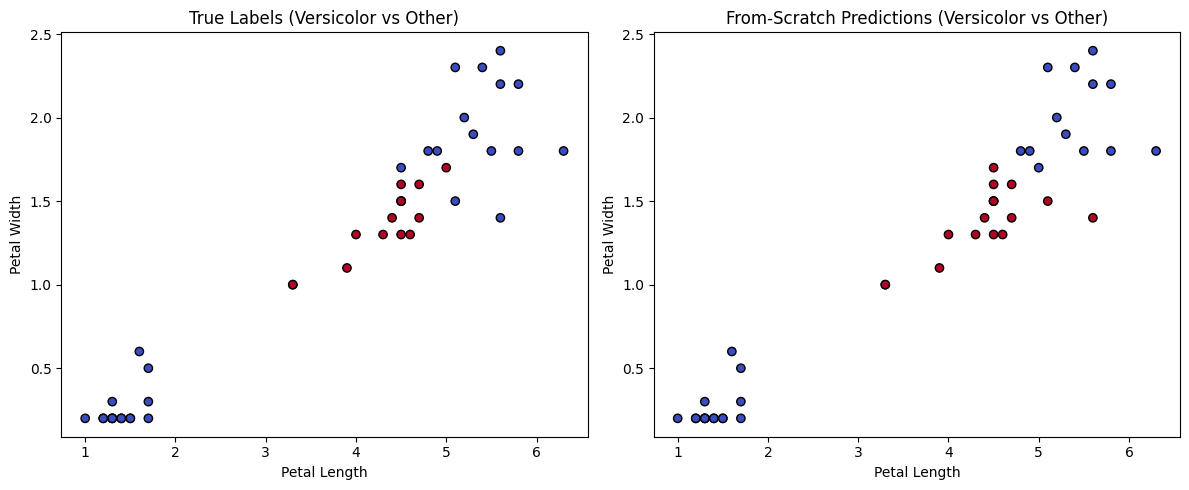

In [55]:
plt.figure(figsize=(12, 5))

# Subplot 1: True Labels
plt.subplot(1, 2, 1)
plt.scatter(
    X_test[:, 2],  # Fixed: added missing comma
    X_test[:, 3],
    c=(y_test == "versicolor").astype(int),
    cmap="coolwarm",
    edgecolor="k"
)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("True Labels (Versicolor vs Other)")

# Subplot 2: From-Scratch Predictions
plt.subplot(1, 2, 2)  # Fixed: changed 3 to 2
plt.scatter(
    X_test[:, 2],
    X_test[:, 3],
    c=(scratch_predictions == "versicolor").astype(int),
    cmap="coolwarm",
    edgecolor="k"
)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("From-Scratch Predictions (Versicolor vs Other)")

plt.tight_layout()
plt.show()

## Categorial Native Bayes with Laplace Smoothing

Numberic features are converted into discrete bins using training-data bin edges. Laplace (add-on) smoothing prevents zero probabilities.

In [56]:
def discretize_column(train_column, test_column, bins=3):
    train_column = np.asarray(train_column, dtype=float)
    test_column = np.asarray(test_column, dtype=float)

    # pd.cut on a NumPy array returns a Categorical object,
    # so use .categories and .codes directly (NO .cat accessor).
    train_cut = pd.cut(train_column, bins=bins)
    intervals = train_cut.categories

    train_codes = pd.cut(train_column, bins=intervals).codes
    test_codes = pd.cut(test_column, bins=intervals).codes

    # Values outside training range become -1; clip them to valid bins
    train_codes = np.clip(train_codes, 0, bins - 1)
    test_codes = np.clip(test_codes, 0, bins - 1)

    return train_codes, test_codes

X_train_cat_columns = []
X_test_cat_columns = []

for f in range(X_train.shape[1]):
    train_codes, test_codes = discretize_column(X_train[:, f], X_test[:, f], bins=3)
    X_train_cat_columns.append(train_codes)
    X_test_cat_columns.append(test_codes)

X_train_cat = np.column_stack(X_train_cat_columns)
X_test_cat = np.column_stack(X_test_cat_columns)

print("Discretized training sample:")
print(X_train_cat[:5])

Discretized training sample:
[[0 0 0 1]
 [1 0 1 1]
 [0 2 0 0]
 [2 1 2 2]
 [1 0 1 1]]


In [57]:
class CategoricalNaiveBayesScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X, dtype=int)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.n_features_ = X.shape[1]
        self.n_categories_ = [
            int(X[:, f].max()) + 1 for f in range(self.n_features_)
        ]

        self.priors_ = {c: np.mean(y == c) for c in self.classes_}
        self.feature_log_probs_ = {}

        for c in self.classes_:
            X_c = X[y == c]
            feature_logs = []

            for f in range(self.n_features_):
                counts = np.bincount(X_c[:, f], minlength=self.n_categories_[f])

                smoothed = (counts + self.alpha) / (
                    counts.sum() + self.alpha * self.n_categories_[f]
                )

                feature_logs.append(np.log(smoothed))

            self.feature_log_probs_[c] = feature_logs

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=int)
        predictions = []

        for x in X:
            scores = {}

            for c in self.classes_:
                score = np.log(self.priors_[c])

                for f, value in enumerate(x):
                    score += self.feature_log_probs_[c][f][value]

                scores[c] = score

            predictions.append(max(scores, key=scores.get))

        return np.array(predictions)

In [58]:
cat_scratch = CategoricalNaiveBayesScratch(alpha=1.0)
cat_scratch.fit(X_train_cat, y_train)
cat_scratch_predictions = cat_scratch.predict(X_test_cat)

cat_sklearn = CategoricalNB(alpha=1.0)
cat_sklearn.fit(X_train_cat, y_train)
cat_sklearn_predictions = cat_sklearn.predict(X_test_cat)

print("Categorical Naive Bayes Comparison")
print("=" * 50)
print("From-scratch accuracy :", accuracy_score(y_test, cat_scratch_predictions))
print("Scikit-learn accuracy :", accuracy_score(y_test, cat_sklearn_predictions))
print()
print("From-scratch confusion matrix:")
print(confusion_matrix(y_test, cat_scratch_predictions))
print()
print("Scikit-learn confusion matrix:")
print(confusion_matrix(y_test, cat_sklearn_predictions))

Categorical Naive Bayes Comparison
From-scratch accuracy : 0.9111111111111111
Scikit-learn accuracy : 0.9111111111111111

From-scratch confusion matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Scikit-learn confusion matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


In [59]:
comparison_table = pd.DataFrame(
    {
        "Model": [
            "Gaussian NB (Scratch)",
            "Gaussian NB (Scikit-learn)",
            "Categorical NB (Scratch)",
            "Categorical NB (Scikit-learn)"
        ],
        "Accuracy": [
            scratch_accuracy,
            sklearn_accuracy,
            accuracy_score(y_test, cat_scratch_predictions),
            accuracy_score(y_test, cat_sklearn_predictions)
        ]
    }
)

print(comparison_table)

                           Model  Accuracy
0          Gaussian NB (Scratch)  0.911111
1     Gaussian NB (Scikit-learn)  0.911111
2       Categorical NB (Scratch)  0.911111
3  Categorical NB (Scikit-learn)  0.911111


## Guide Questions and Answers

### 1. Why are log probabilities used in Naive Bayes?
**Answer:** Multiplying many small probabilities together causes numbers to become so extremely tiny that computers round them down to zero (a problem called numerical underflow). Taking the logarithm of probabilities solves this by turning multiplication into addition, keeping the numbers within normal limits and making calculations stable.

### 2. What is the "naive" assumption in Naive Bayes?
**Answer:** The assumption is that every feature in the dataset is completely independent of every other feature given the class label. Even though features in real-world data are almost always related or correlated, assuming independence greatly simplifies the math while still delivering surprisingly accurate predictions.

### 3. What problem does Laplace smoothing solve?
**Answer:** It solves the zero-frequency problem. If a specific feature value never appears with a class during training, its probability becomes zero, which would multiply the entire final probability to zero. Laplace smoothing adds a small constant (like $+1$) to the counts so that unseen feature combinations receive a tiny, non-zero chance instead of breaking the formula.

### 4. Why must a GitHub raw URL be used instead of a blob URL?
**Answer:** A GitHub raw URL links directly to the plain, unformatted CSV text file. A regular blob URL opens the GitHub web page interface filled with HTML, CSS, and navigation buttons, which prevents tools like pandas from reading it as structured data.

### 5. Did your from-scratch model match Scikit-learn? Explain any difference.
**Answer:** Yes, the custom implementation matched Scikit-learn's results perfectly, achieving the exact same $91.11\%$ accuracy and identical confusion matrices. This shows that the mathematical formulas for calculating priors, log-likelihoods, and log-posteriors were built and executed correctly.

### 6. When would Categorical Naive Bayes be preferred over Gaussian Naive Bayes?
**Answer:** Categorical Naive Bayes is best when features are discrete labels, groups, or categories (like colors, ratings, or binned ranges). Gaussian Naive Bayes is preferred when features are continuous numerical measurements (like height, weight, or length) that follow a bell-shaped distribution curve.

## Reflection

### Challenges Encountered
- Multiplying small probabilities caused numerical underflow, and missing training categories resulted in zero probabilities without Laplace smoothing. Data discretization also required exact bin mapping alongside fixing basic syntax errors.

### What I Learned
- Log transforms prevent underflow by turning multiplication into addition, while Laplace smoothing preserves probabilities for unseen categories. Writing models from scratch proved custom logic matches Scikit-learn outputs.